<a href="https://colab.research.google.com/github/Shiv07ansh/AIML_Lab/blob/main/Midsem_canbus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving attack-free-1.csv to attack-free-1.csv
Saving DoS-1.csv to DoS-1.csv
Saving rpm-1.csv to rpm-1.csv
Saving standstill-1.csv to standstill-1.csv


Check files

In [ ]:
import os

print(os.listdir('/content'))

['.config', 'rpm-1.csv', 'attack-free-1.csv', 'DoS-1.csv', 'standstill-1.csv', 'sample_data']


In [ ]:
import pandas as pd
import numpy as np

Load Datasets

In [ ]:
dos = pd.read_csv('/content/DoS-1.csv')
rpm = pd.read_csv('/content/rpm-1.csv')
standstill = pd.read_csv('/content/standstill-1.csv')
attack_free = pd.read_csv('/content/attack-free-1.csv')

Inspect Data

In [ ]:
print("DoS:")
print(dos.head())

print("\nRPM:")
print(rpm.head())

print("\nStandstill:")
print(standstill.head())

print("\nAttack-free:")
print(attack_free.head())

DoS:
      timestamp arbitration_id        data_field  attack
0  1.672531e+09            1E5  460196E001FE6701       0
1  1.672531e+09            1E9  0010000C00580000       0
2  1.672531e+09            0F9  01B34003167D33FA       0
3  1.672531e+09            2F9        9301000000       0
4  1.672531e+09            199  CFFF0FFFEFFE00FF       0

RPM:
      timestamp arbitration_id        data_field  attack
0  1.672531e+09            0F9  00004000000000FF       0
1  1.672531e+09            199  8FFF0FFFEFFF00FF       0
2  1.672531e+09            19D  C0003FFD001125FF       0
3  1.672531e+09            1E1        00FF110020       0
4  1.672531e+09            1F5  0F0F000100000000       0

Standstill:
      timestamp arbitration_id        data_field  attack
0  1.672531e+09            0C1  3000000430000004       0
1  1.672531e+09            0C5  3000000430000004       0
2  1.672531e+09            184      000200000000       0
3  1.672531e+09            1C7    065CB9A200003F       0
4  1.67

In [ ]:
print("DoS shape:", dos.shape)
print("RPM shape:", rpm.shape)
print("Standstill shape:", standstill.shape)
print("Attack-free shape:", attack_free.shape)

DoS shape: (90169, 4)
RPM shape: (841053, 4)
Standstill shape: (1955048, 4)
Attack-free shape: (1952833, 4)


Inspect Columns

In [ ]:
print("DoS columns:", dos.columns.tolist())
print("RPM columns:", rpm.columns.tolist())
print("Standstill columns:", standstill.columns.tolist())
print("Attack-free columns:", attack_free.columns.tolist())

DoS columns: ['timestamp', 'arbitration_id', 'data_field', 'attack']
RPM columns: ['timestamp', 'arbitration_id', 'data_field', 'attack']
Standstill columns: ['timestamp', 'arbitration_id', 'data_field', 'attack']
Attack-free columns: ['timestamp', 'arbitration_id', 'data_field', 'attack']


Check Datatypes

In [ ]:
print(dos.dtypes)

timestamp         float64
arbitration_id     object
data_field         object
attack              int64
dtype: object


In [ ]:
dos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90169 entries, 0 to 90168
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   timestamp       90169 non-null  float64
 1   arbitration_id  90169 non-null  object 
 2   data_field      90169 non-null  object 
 3   attack          90169 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 2.8+ MB


Check Labels

In [ ]:
print("DoS labels:")
print(dos['attack'].value_counts())

print("\nRPM labels:")
print(rpm['attack'].value_counts())

print("\nStandstill labels:")
print(standstill['attack'].value_counts())

print("\nAttack-free labels:")
print(attack_free['attack'].value_counts())

DoS labels:
attack
0    81030
1     9139
Name: count, dtype: int64

RPM labels:
attack
0    837715
1      3338
Name: count, dtype: int64

Standstill labels:
attack
0    1952833
1       2215
Name: count, dtype: int64

Attack-free labels:
attack
0    1952833
Name: count, dtype: int64


Inspect Attacks

In [ ]:
print("DoS attack examples:")
print(dos[dos['attack'] == 1].head(10))

print("\nRPM attack examples:")
print(rpm[rpm['attack'] == 1].head(10))

print("\nStandstill attack examples:")
print(standstill[standstill['attack'] == 1].head(10))

DoS attack examples:
         timestamp arbitration_id        data_field  attack
4841  1.672531e+09            000  0000000000000000       1
4842  1.672531e+09            000  0000000000000000       1
4843  1.672531e+09            000  0000000000000000       1
4844  1.672531e+09            000  0000000000000000       1
4845  1.672531e+09            000  0000000000000000       1
4846  1.672531e+09            000  0000000000000000       1
4849  1.672531e+09            000  0000000000000000       1
4850  1.672531e+09            000  0000000000000000       1
4855  1.672531e+09            000  0000000000000000       1
4856  1.672531e+09            000  0000000000000000       1

RPM attack examples:
           timestamp arbitration_id      data_field  attack
262181  1.672531e+09            0C9  80000000000018       1
262182  1.672531e+09            0C9  80000000000018       1
262186  1.672531e+09            0C9  80000000000018       1
262191  1.672531e+09            0C9  80000000000018      

In [ ]:
print("DoS attack rows:", len(dos[dos['attack'] == 1]))
print("RPM attack rows:", len(rpm[rpm['attack'] == 1]))
print("Standstill attack rows:", len(standstill[standstill['attack'] == 1]))

DoS attack rows: 9139
RPM attack rows: 3338
Standstill attack rows: 2215


In [ ]:
for name, dataset in [
    ("DoS", dos),
    ("RPM", rpm),
    ("Standstill", standstill),
    ("Attack-free", attack_free)
]:
    lengths = dataset['data_field'].str.len() // 2

    print(f"\n{name}")
    print(lengths.value_counts().sort_index())


DoS
data_field
2     3849
4     8561
5     6276
6     4236
7    10009
8    57238
Name: count, dtype: int64

RPM
data_field
2     39874
4     88504
5     64882
6     43795
7    106830
8    497168
Name: count, dtype: int64

Standstill
data_field
2      93078
4     206259
5     151208
6     102069
7     243412
8    1159022
Name: count, dtype: int64

Attack-free
data_field
2      93078
4     206259
5     151208
6     102069
7     241197
8    1159022
Name: count, dtype: int64


In [ ]:
for name, dataset in [
    ("DoS", dos),
    ("RPM", rpm),
    ("Standstill", standstill),
    ("Attack-free", attack_free)
]:
    odd = dataset['data_field'].str.len() % 2 != 0

    print(name, "odd-length payloads:", odd.sum())

DoS odd-length payloads: 0
RPM odd-length payloads: 0
Standstill odd-length payloads: 0
Attack-free odd-length payloads: 0


In [ ]:
for name, dataset in [
    ("DoS", dos),
    ("RPM", rpm),
    ("Standstill", standstill),
    ("Attack-free", attack_free)
]:
    ids = dataset['arbitration_id'].apply(
        lambda x: int(x, 16)
    )

    print(f"{name}:")
    print("  Min CAN ID:", ids.min())
    print("  Max CAN ID:", ids.max())
    print("  Unique CAN IDs:", ids.nunique())

DoS:
  Min CAN ID: 0
  Max CAN ID: 1919
  Unique CAN IDs: 52
RPM:
  Min CAN ID: 193
  Max CAN ID: 1919
  Unique CAN IDs: 51
Standstill:
  Min CAN ID: 193
  Max CAN ID: 1919
  Unique CAN IDs: 51
Attack-free:
  Min CAN ID: 193
  Max CAN ID: 1919
  Unique CAN IDs: 51


CREATING PRE-PROCESSING FUNCTION

In [ ]:
def preprocess_can(df):
    df = df.copy()

    return df

In [ ]:
def preprocess_can(df):
    df = df.copy()

    # ---------------------------------
    # 1. Remove exact duplicate rows
    # ---------------------------------
    df = df.drop_duplicates()

    # ---------------------------------
    # 2. Convert timestamp to numeric
    # ---------------------------------
    df['timestamp'] = pd.to_numeric(
        df['timestamp'],
        errors='coerce'
    )

    # ---------------------------------
    # 3. Remove rows with invalid
    #    timestamps
    # ---------------------------------
    df = df.dropna(subset=['timestamp'])

    # ---------------------------------
    # 4. Sort chronologically
    # ---------------------------------
    df = df.sort_values(
        'timestamp'
    ).reset_index(drop=True)

    # ---------------------------------
    # 5. Calculate inter-arrival time
    # ---------------------------------
    df['inter_arrival_time'] = df['timestamp'].diff()

    # ---------------------------------
    # 6. Convert CAN arbitration ID
    #    from hexadecimal to integer
    # ---------------------------------
    df['arbitration_id'] = df['arbitration_id'].apply(
        lambda x: int(str(x), 16)
    )

    # ---------------------------------
    # 7. Calculate DLC
    # ---------------------------------
    df['dlc'] = df['data_field'].str.len() // 2

    # ---------------------------------
    # 8. Convert payload into bytes
    # ---------------------------------
    def payload_to_bytes(payload):

        bytes_list = [
            int(payload[i:i+2], 16)
            for i in range(0, len(payload), 2)
        ]

        # Pad shorter CAN frames to 8 bytes
        bytes_list += [0] * (8 - len(bytes_list))

        return bytes_list[:8]

    payload_bytes = df['data_field'].apply(
        payload_to_bytes
    )

    for i in range(8):
        df[f'byte_{i+1}'] = payload_bytes.apply(
            lambda x: x[i]
        )

    return df

In [ ]:
dos_processed = preprocess_can(dos)
rpm_processed = preprocess_can(rpm)
standstill_processed = preprocess_can(standstill)
attack_free_processed = preprocess_can(attack_free)

Inspecting Results

In [ ]:
print(dos_processed.head())

      timestamp  arbitration_id        data_field  attack  inter_arrival_time  \
0  1.672531e+09             485  460196E001FE6701       0                 NaN   
1  1.672531e+09             489  0010000C00580000       0            0.000023   
2  1.672531e+09             249  01B34003167D33FA       0            0.003342   
3  1.672531e+09             761        9301000000       0            0.000057   
4  1.672531e+09             409  CFFF0FFFEFFE00FF       0            0.001098   

   dlc  byte_1  byte_2  byte_3  byte_4  byte_5  byte_6  byte_7  byte_8  
0    8      70       1     150     224       1     254     103       1  
1    8       0      16       0      12       0      88       0       0  
2    8       1     179      64       3      22     125      51     250  
3    5     147       1       0       0       0       0       0       0  
4    8     207     255      15     255     239     254       0     255  


In [ ]:
print(dos_processed.columns.tolist())

['timestamp', 'arbitration_id', 'data_field', 'attack', 'inter_arrival_time', 'dlc', 'byte_1', 'byte_2', 'byte_3', 'byte_4', 'byte_5', 'byte_6', 'byte_7', 'byte_8']


In [ ]:
print(dos_processed.head())
print(dos_processed.dtypes)
print(dos_processed.isnull().sum())

      timestamp  arbitration_id        data_field  attack  inter_arrival_time  \
0  1.672531e+09             485  460196E001FE6701       0                 NaN   
1  1.672531e+09             489  0010000C00580000       0            0.000023   
2  1.672531e+09             249  01B34003167D33FA       0            0.003342   
3  1.672531e+09             761        9301000000       0            0.000057   
4  1.672531e+09             409  CFFF0FFFEFFE00FF       0            0.001098   

   dlc  byte_1  byte_2  byte_3  byte_4  byte_5  byte_6  byte_7  byte_8  
0    8      70       1     150     224       1     254     103       1  
1    8       0      16       0      12       0      88       0       0  
2    8       1     179      64       3      22     125      51     250  
3    5     147       1       0       0       0       0       0       0  
4    8     207     255      15     255     239     254       0     255  
timestamp             float64
arbitration_id          int64
data_field     

VALIDATION BLOCK

In [ ]:
datasets = {
    'DoS': dos_processed,
    'RPM': rpm_processed,
    'Standstill': standstill_processed,
    'Attack-free': attack_free_processed
}

for name, data in datasets.items():
    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")

    print("Shape:", data.shape)
    print("Missing values:")
    print(data.isnull().sum())

    print("\nAttack distribution:")
    print(data['attack'].value_counts())

    print("\nDLC distribution:")
    print(data['dlc'].value_counts().sort_index())

    print("\nUnique CAN IDs:", data['arbitration_id'].nunique())


DoS
Shape: (90169, 14)
Missing values:
timestamp             0
arbitration_id        0
data_field            0
attack                0
inter_arrival_time    1
dlc                   0
byte_1                0
byte_2                0
byte_3                0
byte_4                0
byte_5                0
byte_6                0
byte_7                0
byte_8                0
dtype: int64

Attack distribution:
attack
0    81030
1     9139
Name: count, dtype: int64

DLC distribution:
dlc
2     3849
4     8561
5     6276
6     4236
7    10009
8    57238
Name: count, dtype: int64

Unique CAN IDs: 52

RPM
Shape: (841053, 14)
Missing values:
timestamp             0
arbitration_id        0
data_field            0
attack                0
inter_arrival_time    1
dlc                   0
byte_1                0
byte_2                0
byte_3                0
byte_4                0
byte_5                0
byte_6                0
byte_7                0
byte_8                0
dtype: int64

Attack d

In [ ]:
for name, data in datasets.items():
    print(f"\n{name}")

    iat = data['inter_arrival_time'].dropna()

    print("Minimum:", iat.min())
    print("Maximum:", iat.max())
    print("Mean:", iat.mean())
    print("Median:", iat.median())


DoS
Minimum: 0.0
Maximum: 0.009079217910766602
Mean: 0.00062149030675102
Median: 1.9073486328125e-05

RPM
Minimum: 0.0
Maximum: 0.009550809860229492
Mean: 0.0006888421797716889
Median: 1.1920928955078125e-05

Standstill
Minimum: 0.0
Maximum: 0.009572982788085938
Mean: 0.0006906304938019504
Median: 1.1205673217773438e-05

Attack-free
Minimum: 1.9073486328125e-06
Maximum: 0.00881505012512207
Mean: 0.000691414168744579
Median: 0.00024819374084472656


Time series produced negative diff which we don't want in our ml so we re-wrote the preprocessing function

In [ ]:
datasets = {
    'DoS': dos_processed,
    'RPM': rpm_processed,
    'Standstill': standstill_processed,
    'Attack-free': attack_free_processed
}

for name, data in datasets.items():

    iat = data['inter_arrival_time'].dropna()

    print(f"\n{name}")
    print("Minimum:", iat.min())
    print("Maximum:", iat.max())
    print("Mean:", iat.mean())
    print("Median:", iat.median())
    print("Negative values:", (iat < 0).sum())


DoS
Minimum: 0.0
Maximum: 0.009079217910766602
Mean: 0.00062149030675102
Median: 1.9073486328125e-05
Negative values: 0

RPM
Minimum: 0.0
Maximum: 0.009550809860229492
Mean: 0.0006888421797716889
Median: 1.1920928955078125e-05
Negative values: 0

Standstill
Minimum: 0.0
Maximum: 0.009572982788085938
Mean: 0.0006906304938019504
Median: 1.1205673217773438e-05
Negative values: 0

Attack-free
Minimum: 1.9073486328125e-06
Maximum: 0.00881505012512207
Mean: 0.000691414168744579
Median: 0.00024819374084472656
Negative values: 0


build the balanced experimental dataset.

Step 1 - Create the four classes

In [ ]:
dos_processed['class'] = 'DoS'
rpm_processed['class'] = 'RPM'
standstill_processed['class'] = 'Standstill'
attack_free_processed['class'] = 'Attack-free'

Step 2 — Build the samples carefully

In [ ]:
N_NORMAL = 5000
N_ATTACK = 5000

DOS

In [ ]:
dos_normal = dos_processed[
    dos_processed['attack'] == 0
].sample(
    n=N_NORMAL,
    random_state=42
)

dos_attack = dos_processed[
    dos_processed['attack'] == 1
].sample(
    n=N_ATTACK,
    random_state=42
)

RPM

In [ ]:
# ============================================
# STEP 1: CREATE CONTROLLED EXPERIMENTAL DATASET
# ============================================

# Attack-free: 2,000 normal frames
attack_free_sample = attack_free_processed[
    attack_free_processed['attack'] == 0
].sample(
    n=2000,
    random_state=42
)

# DoS: 2,000 attack frames
dos_attack = dos_processed[
    dos_processed['attack'] == 1
].sample(
    n=2000,
    random_state=42
)

# RPM: 2,000 attack frames
rpm_attack = rpm_processed[
    rpm_processed['attack'] == 1
].sample(
    n=2000,
    random_state=42
)

# Standstill: 2,000 attack frames
standstill_attack = standstill_processed[
    standstill_processed['attack'] == 1
].sample(
    n=2000,
    random_state=42
)

# Add scenario labels
attack_free_sample['class'] = 'Attack-free'
dos_attack['class'] = 'DoS'
rpm_attack['class'] = 'RPM'
standstill_attack['class'] = 'Standstill'

# Combine everything
midsem_df = pd.concat(
    [
        attack_free_sample,
        dos_attack,
        rpm_attack,
        standstill_attack
    ],
    ignore_index=True
)

# Remove the first row of each source if inter-arrival time is NaN
midsem_df = midsem_df.dropna(
    subset=['inter_arrival_time']
).reset_index(drop=True)

# Shuffle the dataset
midsem_df = midsem_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Final shape:", midsem_df.shape)
print("\nClass distribution:")
print(midsem_df['class'].value_counts())

print("\nAttack label distribution:")
print(pd.crosstab(midsem_df['class'], midsem_df['attack']))

Final shape: (8000, 15)

Class distribution:
class
DoS            2000
Attack-free    2000
RPM            2000
Standstill     2000
Name: count, dtype: int64

Attack label distribution:
attack          0     1
class                  
Attack-free  2000     0
DoS             0  2000
RPM             0  2000
Standstill      0  2000


Save the dataset

In [ ]:
midsem_df.to_csv(
    '/content/can_midsem_dataset.csv',
    index=False
)

print("Saved successfully.")

Saved successfully.


Define The ML features

In [ ]:
features = [
    'inter_arrival_time',
    'arbitration_id',
    'dlc',
    'byte_1',
    'byte_2',
    'byte_3',
    'byte_4',
    'byte_5',
    'byte_6',
    'byte_7',
    'byte_8'
]

X = midsem_df[features]
y = midsem_df['class']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8000, 11)
y shape: (8000,)


In [ ]:
X.describe()

,inter_arrival_time,arbitration_id,dlc,byte_1,byte_2,byte_3,byte_4,byte_5,byte_6,byte_7,byte_8
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,0.000928,209.006500,7.195125,40.810375,24.291625,13.554250,21.148125,6.879625,14.505500,22.341125,11.767250
std,0.000909,194.148038,1.006940,58.238401,65.245385,43.499441,58.181628,32.946913,49.474394,36.030078,47.377979
min,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000261,144.750000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000641,201.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24.000000,0.000000
75%,0.001110,201.000000,8.000000,128.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24.000000,0.000000
max,0.007302,1919.000000,8.000000,240.000000,255.000000,255.000000,255.000000,253.000000,255.000000,255.000000,255.000000


In [ ]:
X.isnull().sum()

,0
inter_arrival_time,0
arbitration_id,0
dlc,0
byte_1,0
byte_2,0
byte_3,0
byte_4,0
byte_5,0
byte_6,0
byte_7,0


Stage A — Remove redundant features

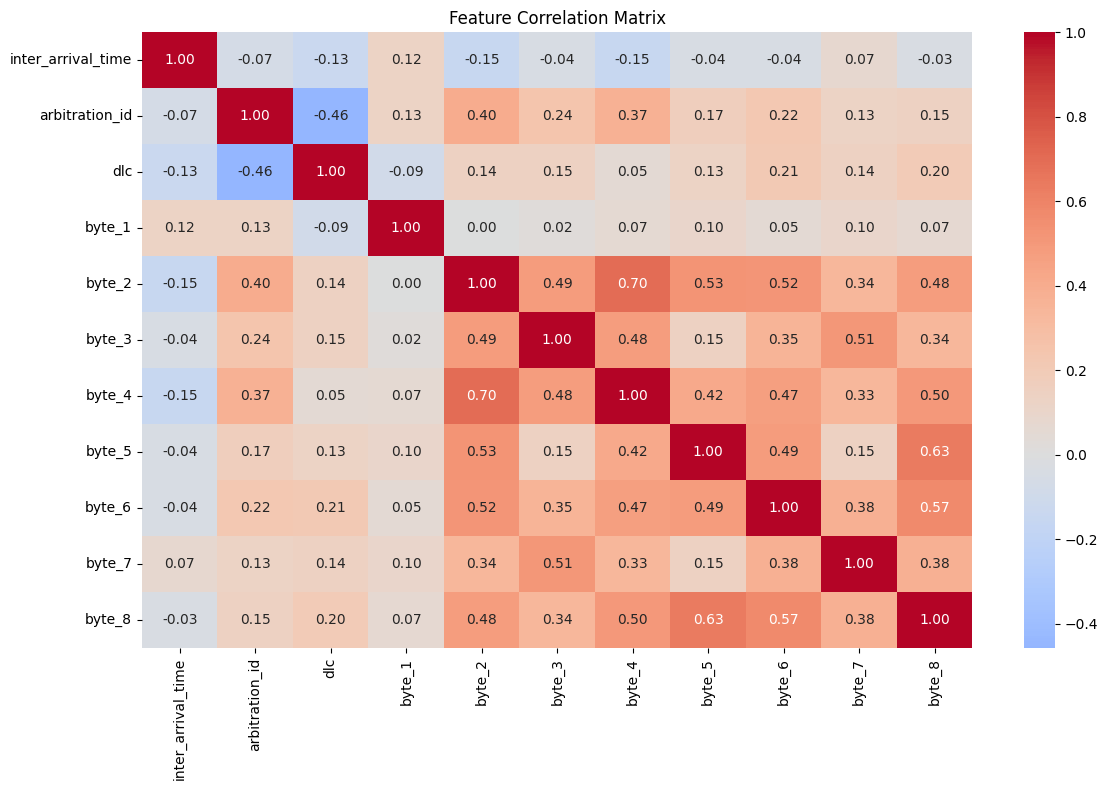

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix
correlation_matrix = X.corr()

# Display correlation matrix
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

Mutual Information

Encode

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:")
print(label_encoder.classes_)

Classes:
['Attack-free' 'DoS' 'RPM' 'Standstill']


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

mi_scores = mutual_info_classif(
    X,
    y_encoded,
    random_state=42
)

mi_results = pd.DataFrame({
    'Feature': features,
    'Mutual Information': mi_scores
})

mi_results = mi_results.sort_values(
    by='Mutual Information',
    ascending=False
).reset_index(drop=True)

mi_results

,Feature,Mutual Information
0,arbitration_id,0.983665
1,byte_7,0.793727
2,byte_1,0.787087
3,dlc,0.666838
4,byte_2,0.351109
5,inter_arrival_time,0.340126
6,byte_4,0.317432
7,byte_3,0.285699
8,byte_6,0.188216
9,byte_8,0.170094


Visualisation

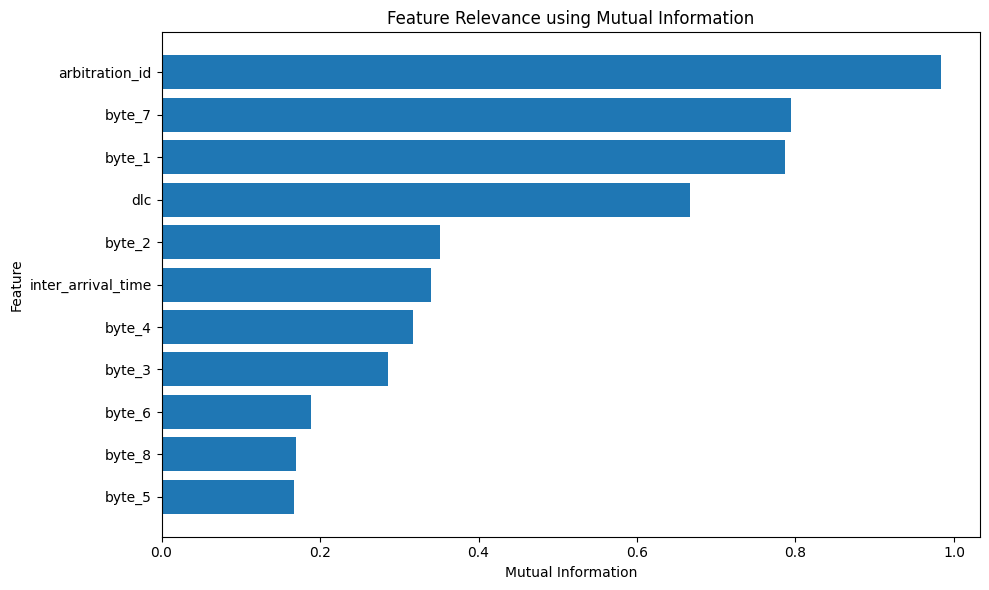

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    mi_results['Feature'],
    mi_results['Mutual Information']
)

plt.xlabel('Mutual Information')
plt.ylabel('Feature')
plt.title('Feature Relevance using Mutual Information')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Split the data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 6400
Testing samples: 1600


Feature Scaling - Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


Models

In [ ]:
LOGISTIC REG

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [ ]:
y_pred_lr = lr_model.predict(X_test_scaled)

print("Predictions generated.")

Predictions generated.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

recall_lr = recall_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy :  {accuracy_lr:.4f}")
print(f"Precision:  {precision_lr:.4f}")
print(f"Recall   :  {recall_lr:.4f}")
print(f"F1-score :  {f1_lr:.4f}")

Logistic Regression Results
---------------------------
Accuracy :  0.9994
Precision:  0.9994
Recall   :  0.9994
F1-score :  0.9994


In [ ]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=label_encoder.classes_
    )
)


Classification Report:
              precision    recall  f1-score   support

 Attack-free       1.00      1.00      1.00       400
         DoS       1.00      1.00      1.00       400
         RPM       1.00      1.00      1.00       400
  Standstill       1.00      1.00      1.00       400

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



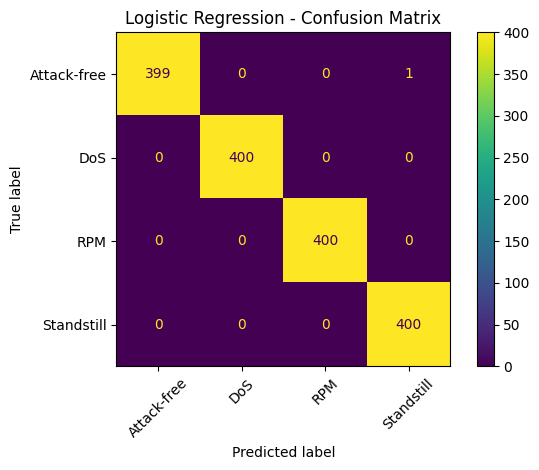

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

SVM

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='linear',
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

print("SVM training completed.")

SVM training completed.


In [ ]:
y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM predictions generated.")

SVM predictions generated.


In [ ]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_svm = precision_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

recall_svm = recall_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

print("SVM Results")
print("---------------------------")
print(f"Accuracy :  {accuracy_svm:.4f}")
print(f"Precision:  {precision_svm:.4f}")
print(f"Recall   :  {recall_svm:.4f}")
print(f"F1-score :  {f1_svm:.4f}")

SVM Results
---------------------------
Accuracy :  1.0000
Precision:  1.0000
Recall   :  1.0000
F1-score :  1.0000


In [ ]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=label_encoder.classes_
    )
)


Classification Report:
              precision    recall  f1-score   support

 Attack-free       1.00      1.00      1.00       400
         DoS       1.00      1.00      1.00       400
         RPM       1.00      1.00      1.00       400
  Standstill       1.00      1.00      1.00       400

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



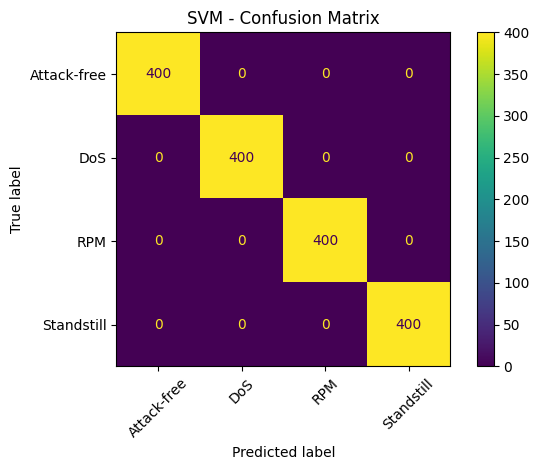

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)

plt.title("SVM - Confusion Matrix")
plt.tight_layout()
plt.show()